# Load Library

In [3]:
!pip install boto3 pandas matplotlib scipy scikit-learn tqdm nibabel optuna torch_geometric torch_cluster einops scikit-image medpy

  Using cached boto3-1.40.46-py3-none-any.whl.metadata (6.7 kB)
  Using cached pandas-2.3.3-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached matplotlib-3.10.6-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.16.2-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (62 kB)
  Using cached scikit_learn-1.7.2-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached nibabel-5.3.2-py3-none-any.whl.metadata (9.1 kB)
  Using cached optuna-4.5.0-py3-none-any.whl.metadata (17 kB)
  Using cached torch_geometric-2.6.1-py3-none-any.whl.metadata (63 kB)
  Using cached torch_cluster-1.6.3.tar.gz (54 kB)
  Preparing metadata (setup.py) ... done
  Using cached einops-0.8.1-py3-none-any.whl.metadata (13 kB)
  Using cached scikit_image-0.25.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.met

In [4]:
# -------------------------
# Core Python & Scientific
# -------------------------
import os
import re
import math
import gc
import random
import itertools
import boto3
from collections import Counter
from torch_geometric.utils import add_self_loops
from torch_geometric.nn import GATv2Conv


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.widgets import Slider
from scipy.ndimage import distance_transform_edt
import scipy.ndimage

# -------------------------
# PyTorch Core
# -------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from torch.autograd import Variable
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts


# -------------------------
# Scikit-learn
# -------------------------
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# -------------------------
# Others
# -------------------------
from tqdm import tqdm
import nibabel as nib
from IPython.display import display
from concurrent.futures import ProcessPoolExecutor
from joblib import Parallel, delayed
import optuna
from optuna.samplers import TPESampler
from torch_geometric.nn import DynamicEdgeConv
from torch_geometric.nn import GATConv
from torch_cluster import radius_graph
from torch_geometric.data import Data, Batch  
from torch_geometric.nn import SAGEConv
from einops import rearrange


from torch_geometric.nn import global_mean_pool
from torch_geometric.nn.aggr import AttentionalAggregation
from torch_geometric.utils import to_dense_batch
from torch_geometric.nn.pool import global_max_pool
from torch_geometric.nn import radius_graph

import numpy as np
from skimage.segmentation import slic
from scipy.spatial.distance import cdist
from scipy import ndimage
import networkx as nx
import torch
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader

import tarfile
import os
import shutil
import tarfile
import tempfile
import subprocess

In [5]:
print(torch.__version__)
print(torch.version.cuda)

2.8.0.dev20250319+cu128
12.8


# Model

In [6]:
class GATModel(nn.Module):
    def __init__(self,
                 in_feats,
                 hidden_dims,
                 out_classes,
                 heads,
                 residuals=True,
                 layer_norm=True,
                 dropout=0.3,
                 attn_drop=0.2,
                 activation=F.elu):
        super(GATModel, self).__init__()

        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList() if layer_norm else None
        self.residuals = residuals
        self.layer_norm = layer_norm
        self.activation = activation
        self.dropout = dropout

        # First GATv2 layer
        self.layers.append(GATv2Conv(in_feats, hidden_dims[0], heads[0], dropout=attn_drop))
        if self.layer_norm:
            self.norms.append(nn.LayerNorm(hidden_dims[0] * heads[0]))

        # Hidden GATv2 layers
        for i in range(1, len(hidden_dims)):
            in_dim = hidden_dims[i - 1] * heads[i - 1]
            self.layers.append(GATv2Conv(in_dim, hidden_dims[i], heads[i], dropout=attn_drop))
            if self.layer_norm:
                self.norms.append(nn.LayerNorm(hidden_dims[i] * heads[i]))

        # Final output layer
        in_dim = hidden_dims[-1] * heads[-1]
        self.out_layer = GATv2Conv(in_dim, out_classes, heads=1, concat=False, dropout=0.0)

    def forward(self, g, features=None):
        x = g.x if features is None else features
        edge_index = g.edge_index

        # Add self-loops if not present (required by GATv2)
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        for i, layer in enumerate(self.layers):
            h = layer(x, edge_index)

            if self.residuals and h.shape == x.shape:
                h = h + x

            if self.layer_norm:
                h = self.norms[i](h)

            h = self.activation(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            x = h

        out = self.out_layer(x, edge_index)
        return out


In [7]:
def node_dice_score(preds, targets, num_classes=4):
    """Computes Dice score for each class based on node labels."""
    dice_scores = []
    for cls in range(num_classes):
        pred_pos = preds == cls
        target_pos = targets == cls
        intersection = np.sum(pred_pos & target_pos)
        union = np.sum(pred_pos) + np.sum(target_pos)
        dice = (2 * intersection) / union if union > 0 else 1.0
        dice_scores.append(dice)
    return dice_scores

def project_graph_predictions_to_voxel(preds, superpixel_map):
    """
    Projects graph-level predictions to voxel space based on the SLIC superpixel map.
    
    preds: (N,) array of predicted labels for N graph nodes.
    superpixel_map: (H, W) or (D, H, W) integer array labeling superpixels.
    """
    output = np.zeros_like(superpixel_map)
    for label in range(len(preds)):
        output[superpixel_map == label] = preds[label]
    return output


def voxel_dice_score(pred_vox, true_vox, num_classes=4):
    scores = []
    for cls in range(num_classes):
        pred_mask = pred_vox == cls
        true_mask = true_vox == cls
        intersection = np.logical_and(pred_mask, true_mask).sum()
        union = pred_mask.sum() + true_mask.sum()
        dice = (2.0 * intersection) / union if union > 0 else 1.0
        scores.append(dice)
    return scores


In [8]:
class TverskyLoss(torch.nn.Module):
    def __init__(self, alpha=0.6, beta=0.4, smooth=1e-6):
        """
        alpha: controls false negatives (high alpha = penalize false negatives more)
        beta: controls false positives (high beta = penalize false positives more)
        """
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, logits, targets):
        """
        logits: (N, C) raw predictions from model
        targets: (N,) ground truth labels
        """
        num_classes = logits.shape[1]
        probs = F.softmax(logits, dim=1)
        one_hot = F.one_hot(targets, num_classes).float()

        dims = [0]  # over nodes

        TP = torch.sum(probs * one_hot, dim=dims)
        FP = torch.sum(probs * (1 - one_hot), dim=dims)
        FN = torch.sum((1 - probs) * one_hot, dim=dims)

        tversky = (TP + self.smooth) / (TP + self.alpha * FN + self.beta * FP + self.smooth)
        return 1 - tversky.mean()

class GNNSegmentationLoss(torch.nn.Module):
    def __init__(self, class_weights=None, alpha=0.5, beta=0.5, ce_weight=0.5):
        super().__init__()
        self.ce = torch.nn.CrossEntropyLoss(weight=class_weights)
        self.tversky = TverskyLoss(alpha=alpha, beta=beta)
        self.w = ce_weight  # weight for ce

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        tv_loss = self.tversky(logits, targets)
        return (self.w) * ce_loss +  tv_loss


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

in_feats = 20
hidden_dims = [64, 64]         # Important: GAT uses [out_channels per head]
out_classes = 4

gnn_model = GATModel(
    in_feats=in_feats,
    hidden_dims=hidden_dims,
    out_classes=out_classes,
    heads=[4, 4],
    residuals=True,
    layer_norm=True,
    dropout=0.3,
    attn_drop=0.2
).to(device)

# ---------- Config ----------
lr = 1e-4
weight_decay = 1e-4
T_0 = 10  # Epochs before restart
T_mult = 2
eta_min = 1e-5

# ---------- Optimizer + Scheduler ----------
optimizer = AdamW(gnn_model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=T_0, T_mult=T_mult, eta_min=eta_min)

# ---------- AMP Scaler ----------
scaler = GradScaler()



loss_fn = GNNSegmentationLoss().to(device)  # adjust weights if needed


In [10]:
def train_one_epoch(model, data_loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    progress = tqdm(data_loader, desc="Training", leave=False)
    for batch in progress:
        batch = batch.to(device)
        optimizer.zero_grad()

        logits = model(batch)              # [num_nodes, num_classes]
        labels = batch.y                  # [num_nodes]
        loss = loss_fn(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.append(logits.argmax(dim=1).detach().cpu())
        all_labels.append(labels.detach().cpu())
        progress.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(data_loader)
    return avg_loss, torch.cat(all_preds), torch.cat(all_labels)


In [11]:
def calculate_node_dices(preds, labels, num_classes=None):
    """
    Calculates Dice score for each class.
    Always returns num_classes scores.
    """
    from sklearn.metrics import f1_score
    if num_classes is None:
        num_classes = np.max(labels) + 1

    dice_scores = []
    for cls in range(num_classes):
        pred_cls = (preds == cls).astype(int)
        label_cls = (labels == cls).astype(int)
        if np.sum(label_cls) == 0:
            dice_scores.append(0.0)  # instead of skip
            continue
        score = f1_score(label_cls, pred_cls)
        dice_scores.append(score)
    return dice_scores

    
def evaluate_gnn(model, data_loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Validating", leave=False):
            batch = batch.to(device)

            logits = model(batch)              # [num_nodes, num_classes]
            labels = batch.y                  # [num_nodes]
            loss = loss_fn(logits, labels)

            total_loss += loss.item()
            all_preds.append(logits.argmax(dim=1).detach().cpu())
            all_labels.append(labels.detach().cpu())

    avg_loss = total_loss / len(data_loader)
    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    dice = calculate_node_dices(preds, labels)

    return avg_loss, list(dice)


# Preprocessing

In [12]:
# ---------------- Preprocessing ----------------

def percentile_normalize(image, lower=0.5, upper=99.5):
    mask = image > 0
    if not mask.any():
        return image
    lo = np.percentile(image[mask], lower)
    hi = np.percentile(image[mask], upper)
    img = np.clip(image, lo, hi)
    return (img - img[mask].mean()) / (img[mask].std() + 1e-8)

def pad_depth(vol, target_depth=160):
    is_tensor = isinstance(vol, torch.Tensor)
    current_depth = vol.shape[-1]
    diff = current_depth - target_depth

    if diff == 0:
        return vol

    if diff > 0:
        front_crop = diff // 2
        back_crop = diff - front_crop
        return vol[..., front_crop:-back_crop]

    front_pad = (-diff) // 2
    back_pad = (-diff) - front_pad
    if is_tensor:
        return F.pad(vol, (front_pad, back_pad))
    else:
        return np.pad(vol, [(0, 0)] * (vol.ndim - 1) + [(front_pad, back_pad)], mode='constant')

def center_crop_xy(img, lbl, size=192):
    C, H, W, D = img.shape
    sh = (H - size) // 2
    sw = (W - size) // 2
    img = img[:, sh:sh + size, sw:sw + size, :]
    lbl = lbl[sh:sh + size, sw:sw + size, :]
    return img, lbl

# ---------------- Dataset ----------------

class BraTSSliceDataset(Dataset):
    def __init__(self, slice_index, feature_dir, target_dir,
                 modalities=['t1n', 't1c', 't2f', 't2w'],
                 crop_val=False, target_depth=144, debug_visual=False):
        self.slice_index = slice_index
        self.feature_dir = feature_dir
        self.target_dir = target_dir
        self.modalities = modalities
        self.crop_val = crop_val
        self.target_depth = target_depth
        self.debug_visual = debug_visual

    def __len__(self):
        return len(self.slice_index)

    def __getitem__(self, idx):
        sid, slice_idx = self.slice_index[idx]
        vols = []

        for m in self.modalities:
            path = os.path.join(self.feature_dir, f"{sid}__{sid}-{m}.nii.gz")
            img = nib.load(path).get_fdata()
            img = percentile_normalize(img)
            vols.append(img)

        image = np.stack(vols, axis=0)
        label_path = os.path.join(self.target_dir, f"{sid}__{sid}-seg.nii.gz")
        label = nib.load(label_path).get_fdata().astype(np.int64)

        image = pad_depth(image, self.target_depth)
        label = pad_depth(label, self.target_depth)

        if self.crop_val:
            image, label = center_crop_xy(image, label, size=self.crop_val)

        image_slice = torch.from_numpy(image[..., slice_idx]).float()
        label_slice = torch.from_numpy(label[..., slice_idx]).long()

        if self.debug_visual:
            self.visualize(image_slice, label_slice, sid, slice_idx)

        return image_slice, label_slice

    def visualize(self, image, label, sid, idx):
        import matplotlib.pyplot as plt
        fig, axs = plt.subplots(1, 2, figsize=(8, 4))
        axs[0].imshow(label.numpy(), cmap='gray')
        axs[0].set_title(f"GT Label: {sid} [{idx}]")
        axs[1].imshow(image[0].numpy(), cmap='gray')
        axs[1].set_title(f"Modality 0: {sid}")
        plt.tight_layout()
        plt.show()

# ---------------- Split Function ----------------

def get_train_val_datasets(feature_dir, target_dir,
                           slice_train_ratio=1.0,
                           tumor_ratio=0.5,
                           crop_val=False, target_depth=144,
                           debug_visual=False, limit_subjects=None, seed=42):
    all_files = os.listdir(feature_dir)
    subjs = sorted({f.split('__')[0] for f in all_files if f.endswith('.nii.gz')})
    if limit_subjects:
        subjs = subjs[:limit_subjects]

    all_slices = []

    tumor_slices = []
    non_tumor_slices = []

    print("[Slice Indexing] Scanning all slices...")
    for sid in subjs:
        label_path = os.path.join(target_dir, f"{sid}__{sid}-seg.nii.gz")
        label = nib.load(label_path).get_fdata().astype(np.int64)
        label = pad_depth(label, target_depth)

        for d in range(label.shape[-1]):
            slice_lbl = label[..., d]
            entry = (sid, d)
            all_slices.append(entry)
            if np.any(slice_lbl > 0):
                tumor_slices.append(entry)
            else:
                non_tumor_slices.append(entry)

    # Shuffle once
    random.seed(seed)
    random.shuffle(all_slices)

    # Slice-based split (not subject)
    total_slices = len(all_slices)
    num_train = int(slice_train_ratio * total_slices)

    train_index_full = all_slices[:num_train]
    val_index = all_slices[num_train:]

    # Now filter train_index by tumor_ratio
    tumor_train = [x for x in train_index_full if x in tumor_slices]
    non_tumor_train = [x for x in train_index_full if x in non_tumor_slices]

    desired_tumor = int(tumor_ratio * num_train)
    desired_non_tumor = num_train - desired_tumor

    train_index = tumor_train[:desired_tumor] + non_tumor_train[:desired_non_tumor]
    random.shuffle(train_index)

    print(f"Total slices: {total_slices}")
    print(f"Train slices: {len(train_index)} (Tumor ratio: {tumor_ratio})")
    print(f"Val slices:   {len(val_index)} (unfiltered)")

    train_ds = BraTSSliceDataset(train_index, feature_dir, target_dir,
                                 crop_val=crop_val, target_depth=target_depth,
                                 debug_visual=debug_visual)
    val_ds = BraTSSliceDataset(val_index, feature_dir, target_dir,
                               crop_val=crop_val, target_depth=target_depth,
                               debug_visual=debug_visual)

    return train_ds, val_ds


# Convert into graph (function)

In [23]:
#Graph conversion 
# Set this to whatever your model expects (20 from the warning). You can also override via env.
FEATURE_WIDTH = int(os.environ.get("GRAPH_FEAT_DIM", "20"))

from torch_geometric.data import Data

FEATURE_WIDTH = int(os.environ.get("GRAPH_FEAT_DIM", "20"))

def _fix_width(x: torch.Tensor, target_f: int = FEATURE_WIDTH) -> torch.Tensor:
    if x.dtype != torch.float32:
        x = x.float()
    if x.dim() == 1:
        x = x.view(-1, 1)
    if x.size(-1) < target_f:
        x = torch.cat([x, x.new_zeros(x.size(0), target_f - x.size(-1))], dim=1)
    elif x.size(-1) > target_f:
        x = x[:, :target_f]
    return x

def pyg_from_networkx(G):
    n_nodes = G.number_of_nodes()
    if n_nodes == 0:
        return None  # invalid sample, skip

    # collect features, pad per-graph, then fix global width
    feats_list, max_len = [], 0
    for _, ndata in G.nodes(data=True):
        f = ndata.get('features', [])
        if not isinstance(f, (list, tuple)):
            f = [float(f)]
        max_len = max(max_len, len(f))
        feats_list.append(f)

    if max_len == 0:
        x = torch.zeros((n_nodes, FEATURE_WIDTH), dtype=torch.float32)
    else:
        padded = [fi + [0.0]*(max_len - len(fi)) for fi in feats_list]
        x = torch.as_tensor(padded, dtype=torch.float32)
        x = _fix_width(x, FEATURE_WIDTH)

    # optional labels
    y = None
    has_label = all(('label' in ndata) for _, ndata in G.nodes(data=True))
    if has_label:
        y = torch.as_tensor([int(ndata['label']) for _, ndata in G.nodes(data=True)], dtype=torch.long)

    # edges
    edge_list = list(G.edges)
    if not edge_list:
        # at least self-loops to avoid empty edge_index
        idx = torch.arange(n_nodes, dtype=torch.long)
        edge_index = torch.stack([idx, idx], dim=0)
    else:
        edge_index = torch.as_tensor(edge_list, dtype=torch.long).t().contiguous()
        if not G.is_directed():
            edge_index = torch.cat([edge_index, edge_index[[1, 0]]], dim=1)

    data = Data(x=x, edge_index=edge_index)
    if y is not None:
        data.y = y
    return data


def majority_vote(arr):
    values, counts = np.unique(arr, return_counts=True)
    return values[np.argmax(counts)]


def compute_quantiles(x):
    return np.quantile(x, [0.1, 0.25, 0.5, 0.75, 0.9])


def summarize_modality(modality, labels, n_segments):
    return np.stack([
        compute_quantiles(modality[labels == i]) if np.any(labels == i) else np.zeros(5)
        for i in range(n_segments)
    ], axis=0)


def analyze_regions(sv_map, image_data, ground_truth, n_segments):
    if image_data.ndim == 3:
        summaries = [
            summarize_modality(image_data[..., i], sv_map, n_segments)
            for i in range(image_data.shape[-1])
        ]
        node_features = np.concatenate(summaries, axis=-1)
    else:
        node_features = summarize_modality(image_data, sv_map, n_segments)

    region_labels = np.array([
        majority_vote(ground_truth[sv_map == i]) if np.any(sv_map == i) else 0
        for i in range(n_segments)
    ])

    centers = np.array(ndimage.center_of_mass(np.ones_like(sv_map), sv_map, range(n_segments)))
    return node_features, centers, region_labels


def filter_invalid_regions(sv_map, features, centers, labels, n_segments):
    baseline = np.min(features[:, 4]) + 0.01
    valid = features[:, 4] >= baseline

    mapping = -np.ones(n_segments, dtype=np.int16)
    next_index = 0
    for i in range(n_segments):
        if valid[i]:
            mapping[i] = next_index
            next_index += 1

    updated_map = mapping[sv_map]
    return updated_map, features[valid], centers[valid], labels[valid]


def extract_graph_components(sv_map, image_data, ground_truth, n_segments):
    feats, centers, lbls = analyze_regions(sv_map, image_data, ground_truth, n_segments)
    return filter_invalid_regions(sv_map, feats, centers, lbls, n_segments)


def generate_knn_adjacency(centers, features, k, weighted=True, strict=True):
    pos_dists = cdist(centers, centers)
    adjacency = np.zeros_like(pos_dists)

    if strict:
        for i in range(len(pos_dists)):
            neighbors = np.argsort(pos_dists[i])[1:k+1]
            adjacency[i, neighbors] = 1
            adjacency[neighbors, i] = 1
    else:
        for i in range(len(pos_dists)):
            neighbors = np.argsort(pos_dists[i])[:k]
            adjacency[i, neighbors] = 1

    if weighted:
        feat_dists = cdist(features, features)
        feat_dists /= feat_dists.max()
        sigma = 0.1
        weights = np.exp(-feat_dists ** 2 / (2 * sigma ** 2))
        return adjacency * weights

    return adjacency


def spatial_adjacency(region_map, n_nodes, return_matrix=False):
    region_map = region_map.copy()
    region_map[region_map == -1] = n_nodes
    tmp = np.zeros((n_nodes + 1, n_nodes + 1), dtype=bool)

    if region_map.ndim == 3:
        for axis in range(3):
            slices = [slice(None)] * 3
            slices[axis] = slice(1, None)
            a = region_map[tuple(slices)]
            slices[axis] = slice(None, -1)
            b = region_map[tuple(slices)]
            tmp[a[a != b], b[a != b]] = True
    else:
        a, b = region_map[:-1, :], region_map[1:, :]
        tmp[a[a != b], b[a != b]] = True
        a, b = region_map[:, :-1], region_map[:, 1:]
        tmp[a[a != b], b[a != b]] = True

    adj = (tmp | tmp.T)[:-1, :-1]
    np.fill_diagonal(adj, True)
    if return_matrix:
        return adj
    return np.where(adj)


def convert_image_to_graph(image_data, label_map=None, target_segments=5000, slic_compactness=0.5, neighbors=10):
    from packaging import version
    from skimage import __version__ as skimage_version

    has_gt = label_map is not None
    if not has_gt:
        label_map = np.zeros(image_data.shape[:2], dtype=np.int16)

    is_multichannel = image_data.ndim == 3
    skimage_args = {
        'image': image_data.astype(np.float64),
        'n_segments': target_segments,
        'sigma': 1,
        'compactness': slic_compactness,
        'convert2lab': False,
        'start_label': 0
    }

    if version.parse(skimage_version) >= version.parse("0.19"):
        skimage_args['channel_axis'] = -1 if is_multichannel else None
    else:
        skimage_args['multichannel'] = is_multichannel

    regions = slic(**skimage_args).astype(np.int16)
    n_regions = regions.max() + 1

    new_map, features, centers, labels = extract_graph_components(regions, image_data, label_map, n_regions)

    if neighbors:
        adj = generate_knn_adjacency(centers, features, neighbors, weighted=False, strict=True)
    else:
        adj = spatial_adjacency(new_map, len(labels), return_matrix=True)

    G = nx.from_numpy_array(adj)
    for i in G.nodes:
        G.nodes[i]['features'] = features[i].tolist()
        if has_gt:
            G.nodes[i]['label'] = int(labels[i])
        G.nodes[i]['pos'] = (centers[i][1], centers[i][0])  # (x, y)

    return G, features, image_data, new_map, label_map


def batch_graph_conversion(batch_images, batch_labels, **kwargs):
    from joblib import Parallel, delayed

    def process_slice(i):
        img_np = batch_images[i].permute(1, 2, 0).numpy()  # (4, H, W) -> (H, W, 4)
        lbl_np = batch_labels[i].numpy()
        return convert_image_to_graph(img_np, lbl_np, **kwargs)

    results = Parallel(n_jobs=-1)(
        delayed(process_slice)(i) for i in range(batch_images.shape[0])
    )

    return [(G, new_map, image_data, label_map) for (G, _, image_data, new_map, label_map) in results]


# Convertion

In [19]:
# Load dataset
feature_dir = "/workspace/BraTS_features"
target_dir = "/workspace/BraTS_target"

train_ds, val_ds = get_train_val_datasets(feature_dir, target_dir, slice_train_ratio=0.8,
    limit_subjects=1000,
    seed=42000, crop_val = 160
)


NUM_CPU = 14
LOADER_KW = dict(
    num_workers=NUM_CPU,        # 8 parallel workers 
    pin_memory=True,            # faster host→GPU copies
    persistent_workers=True
)

train_loader = DataLoader(
    train_ds,
    batch_size=5,
    shuffle=True,
    drop_last=False,
    **LOADER_KW
)

val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False,
    **LOADER_KW
)


[Slice Indexing] Scanning all slices...
Total slices: 144000
Train slices: 89050 (Tumor ratio: 0.5)
Val slices:   28800 (unfiltered)


In [29]:
def add_safe_globals(allowlist=None):
    """Return globals dict with only allowed classes for unpickling."""
    safe = {}
    if allowlist:
        for cls in allowlist:
            safe[cls.__name__] = cls
    return safe
    
# --- Allowlist for PyTorch >= 2.6 unpickling (networkx graph in .pt) ---
add_safe_globals([nx.Graph])

# -------- CONFIG: set your Drive folders + rclone remote ----------
RCLONE_REMOTE = "gdrive"  # <-- change if your rclone remote is different
TRAIN_FOLDER  = "1ZLauFikqHgHU0DTLXd7Fbt_CJN4jcQ3l"
VAL_FOLDER    = "1BvvEDr55CCvjAZ1f1_kQ_ISQdu_Gq406"

# ---------- UTIL: rclone helpers ----------
def _rclone_copy_file_to_folder(local_path, folder_id, remote=RCLONE_REMOTE):
    """
    Upload a single local file into a specific Drive folder (by ID).
    Uses `rclone copy` (directory dest OK) with --drive-root-folder-id=folder_id.
    """
    subprocess.run([
        "rclone", "copy",
        local_path, f"{remote}:",
        "--drive-root-folder-id", folder_id,
        "--drive-chunk-size", "64M",
        "--transfers", "8", "--checkers", "8",
        "--quiet"
    ], check=True)

def _rclone_list(folder_id, ext, remote=RCLONE_REMOTE):
    """List filenames in a Drive folder by ID filtered by extension."""
    out = subprocess.check_output(
        ["rclone", "lsf", f"{remote}:", "--drive-root-folder-id", folder_id,
         "--files-only", "--format", "p"],
        text=True
    )
    files = sorted([ln.strip() for ln in out.splitlines() if ln.strip().endswith(ext)])
    return files

def _rclone_copyto(local_dest_path, folder_id, filename, remote=RCLONE_REMOTE, quiet=True):
    """
    Download exactly one file by name from the folder ID to a local path.
    """
    cmd = [
        "rclone", "copyto", os.path.join(f"{remote}:", filename), local_dest_path,
        "--drive-root-folder-id", folder_id
    ]
    if quiet: cmd.append("--quiet")
    subprocess.run(cmd, check=True)





# ---------- PART 1: Build & upload bundles ----------
def build_and_upload_bundles(
    loader, folder_id, tag,
    *, bundle_size=500,             # e.g., 500~1200 for speed
    target_segments=700, slic_compactness=0.3, neighbors=11,
    staging_dir="bundle_stage"
):
    """
    Iterate your DataLoader -> run batch_graph_conversion -> accumulate N graphs ->
    write a tar.gz bundle of .pt files -> upload to Drive -> clear staging -> repeat.
    """
    os.makedirs(staging_dir, exist_ok=True)
    pt_dir = os.path.join(staging_dir, "pts")
    os.makedirs(pt_dir, exist_ok=True)
    bundle_idx, in_bundle = 0, 0

    def _flush_bundle():
        nonlocal bundle_idx, in_bundle
        if in_bundle == 0:
            return
        tar_name = f"{tag}_bundle_{bundle_idx:05d}.tar.gz"
        tar_path = os.path.join(staging_dir, tar_name)

        # Tar up all .pt in pt_dir
        with tarfile.open(tar_path, "w:gz") as tar:
            for f in sorted(os.listdir(pt_dir)):
                if f.endswith(".pt"):
                    tar.add(os.path.join(pt_dir, f), arcname=f)

        # Upload tar into the Drive folder by ID, then clean
        _rclone_copy_file_to_folder(tar_path, folder_id)
        os.remove(tar_path)
        shutil.rmtree(pt_dir, ignore_errors=True)
        os.makedirs(pt_dir, exist_ok=True)

        in_bundle = 0
        bundle_idx += 1

    pbar = tqdm(loader, desc=f"Bundling → Drive [{tag}]", unit="batch")
    for batch_images, batch_labels in pbar:
        graphs_list = batch_graph_conversion(
            batch_images, batch_labels,
            target_segments=target_segments,
            slic_compactness=slic_compactness,
            neighbors=neighbors
        )
        # Save each graph tuple as its own .pt into staging dir
        for _g in graphs_list:
            fname = f"g_{tag}_{bundle_idx:05d}_{in_bundle:06d}.pt"
            fpath = os.path.join(pt_dir, fname)
            torch.save(_g, fpath)
            in_bundle += 1
            if in_bundle >= bundle_size:
                _flush_bundle()

        # free
        del graphs_list, batch_images, batch_labels

    # leftover bundle
    _flush_bundle()
    shutil.rmtree(staging_dir, ignore_errors=True)
    print(f"[DONE] Uploaded {bundle_idx} bundles for tag='{tag}' to folder {folder_id}")


In [21]:
# Build & upload train bundles (e.g., 1000 graphs per tar)
build_and_upload_bundles(
    train_loader, TRAIN_FOLDER, "train",
    bundle_size=1000,  # 200–1000 works; larger = fewer Drive ops (faster)
    target_segments=2500, slic_compactness=0.2, neighbors=11
)


# Build & upload val bundles
build_and_upload_bundles(
    val_loader, VAL_FOLDER, "val",
    bundle_size=1000,
    target_segments=2500, slic_compactness=0.2, neighbors=11
)


Bundling → Drive [val]:  56%|█████▌    | 3999/7200 [2:29:51<1:00:13,  1.13s/batch]2025/10/06 04:29:42 ERROR : val_bundle_00015.tar.gz: Failed to copy: googleapi: Error 403: Quota exceeded for quota metric 'Queries' and limit 'Queries per minute' of service 'drive.googleapis.com' for consumer 'project_number:202264815644'.
Details:
[
  {
    "@type": "type.googleapis.com/google.rpc.ErrorInfo",
    "domain": "googleapis.com",
    "metadata": {
      "consumer": "projects/202264815644",
      "quota_limit": "defaultPerMinutePerProject",
      "quota_limit_value": "420000",
      "quota_location": "global",
      "quota_metric": "drive.googleapis.com/default",
      "quota_unit": "1/min/{project}",
      "service": "drive.googleapis.com"
    },
    "reason": "RATE_LIMIT_EXCEEDED"
  },
  {
    "@type": "type.googleapis.com/google.rpc.Help",
    "links": [
      {
        "description": "Request a higher quota limit.",
        "url": "https://cloud.google.com/docs/quotas/help/request_increas

[DONE] Uploaded 29 bundles for tag='val' to folder 1BvvEDr55CCvjAZ1f1_kQ_ISQdu_Gq406


# Train Function

In [31]:
# ---------- Imports ----------
import os, shutil, tarfile, tempfile, subprocess, time, random
from pathlib import Path
from typing import List, Tuple, Optional, Iterable

import numpy as np
from tqdm import tqdm

# ---------- REQUIRED: point this to your Pod volume ----------
STORAGE_ROOT = os.environ.get("BUNDLE_STORAGE_ROOT", "/workspace")  # <--- CHANGE if needed
os.makedirs(STORAGE_ROOT, exist_ok=True)

# Train / Val Google Drive folder IDs (from your URLs)
TRAIN_FOLDER = "1ZLauFikqHgHU0DTLXd7Fbt_CJN4jcQ3l"
VAL_FOLDER   = "1BvvEDr55CCvjAZ1f1_kQ_ISQdu_Gq406"

# Make all tempfile.* calls use the volume by default
tempfile.tempdir = STORAGE_ROOT
os.environ["TMPDIR"] = STORAGE_ROOT
os.environ["TEMP"]  = STORAGE_ROOT
os.environ["TMP"]   = STORAGE_ROOT

# Allowlist for PyTorch >= 2.6 unpickling of networkx graphs
add_safe_globals([nx.Graph])

# ---------- Rclone config ----------
RCLONE_REMOTE = "gdrive"
RCLONE_COMMON_FLAGS = [
    "--drive-chunk-size", "64M",
    "--transfers", "4", "--checkers", "4",
    "--retries", "10", "--low-level-retries", "20",
    "--tpslimit", "5", "--tpslimit-burst", "10",
    "--drive-pacer-min-sleep", "200ms", "--drive-pacer-burst", "200",
    "--quiet",
]

NUM_CPU = max(1, (os.cpu_count() or 8) - 1)

# You must define these IDs elsewhere in your code/notebook:
# TRAIN_FOLDER = "<Google Drive folder ID for train>"
# VAL_FOLDER   = "<Google Drive folder ID for val>"


# ---------- Disk helpers ----------
def bytes_h(n: int) -> str:
    for u in ["B","KB","MB","GB","TB"]:
        if n < 1024: return f"{n:.1f}{u}"
        n /= 1024
    return f"{n:.1f}PB"

def free_bytes(path: str = STORAGE_ROOT) -> int:
    usage = shutil.disk_usage(path)
    return usage.free

def assert_free_space(need_bytes: int, path: str = STORAGE_ROOT, head: str = ""):
    fb = free_bytes(path)
    if fb < need_bytes:
        raise OSError(
            f"[{head}] Not enough free space on {path}: "
            f"need≈{bytes_h(need_bytes)} > free={bytes_h(fb)}"
        )


# ---------- Tar safety ----------
def _safe_extractall(tar: tarfile.TarFile, path: str):
    """
    Prevent path traversal (CVE-2007-4559 class).
    """
    base = os.path.abspath(path)
    for m in tar.getmembers():
        dest = os.path.abspath(os.path.join(path, m.name))
        if not dest.startswith(base + os.sep) and dest != base:
            raise Exception(f"Blocked unsafe member: {m.name}")
    tar.extractall(path=path)


# ---------- Subprocess helpers ----------
def _run(cmd: List[str]) -> str:
    """Run a command and return stdout as text; raise with readable output on failure."""
    try:
        return subprocess.check_output(cmd, text=True, stderr=subprocess.STDOUT)
    except subprocess.CalledProcessError as e:
        raise RuntimeError(f"Command failed: {' '.join(cmd)}\n{e.output}") from e


# ---------- Rclone helpers ----------
import subprocess
from typing import List, Tuple

def list_bundles(folder_id: str,
                 remote: str = "gdrive",
                 max_depth: int = 5) -> List[Tuple[str, int]]:
    """
    Return [(path, size_bytes)] for *.tar.gz files under Drive folder `folder_id`.
    Handles rclone `lsf` output that uses ';' as the separator.
    """
    cmd = [
        "rclone", "lsf", f"{remote}:",
        "--drive-root-folder-id", folder_id,
        "--files-only",
        "--format", "ps",          # PATH then SIZE
        "--separator", ";",        # <-- force ';' so we know what to split on
        "--max-depth", str(max_depth),
        "--quiet",
    ]
    out = subprocess.check_output(cmd, text=True, stderr=subprocess.STDOUT)

    files: List[Tuple[str, int]] = []
    for ln in out.splitlines():
        ln = ln.strip()
        if not ln:
            continue
        # 'ps' with separator ';' -> "<path>;<size>"
        if ";" in ln:
            path, size_str = ln.rsplit(";", 1)
        else:
            # fallback: try space-delimited "<path> <size>"
            parts = ln.rsplit(maxsplit=1)
            if len(parts) != 2:
                continue
            path, size_str = parts

        if path.endswith("/") or not path.lower().endswith(".tar.gz"):
            continue
        try:
            sz = int(size_str)
        except ValueError:
            continue
        files.append((path, sz))

    files.sort(key=lambda t: t[0])
    if not files:
        print("[list_bundles] Still empty. First raw lines:\n",
              "\n".join(out.splitlines()[:10]) or "<empty>")
    return files


def _rclone_copyto(src_remote_path: str,
                   local_path: str,
                   folder_id: str,
                   *,
                   remote: str = RCLONE_REMOTE,
                   max_tries: int = 6,
                   extra_flags: list[str] = None):
    """
    Copy a single file FROM Drive (resolved via --drive-root-folder-id) TO local_path.
    src_remote_path must be like 'gdrive:train_bundle_00025.tar.gz'
    """
    flags = RCLONE_COMMON_FLAGS if extra_flags is None else extra_flags
    cmd = [
        "rclone", "copyto",
        src_remote_path,            # e.g. gdrive:train_bundle_00025.tar.gz
        local_path,                 # e.g. /workspace/tmp/tars/train_bundle_00025.tar.gz
        "--drive-root-folder-id", folder_id,
        *flags
    ]
    for i in range(max_tries):
        try:
            subprocess.run(cmd, check=True)
            return
        except subprocess.CalledProcessError as e:
            if i == max_tries - 1:
                raise RuntimeError(
                    "rclone copyto failed\n"
                    f"cmd: {' '.join(cmd)}\n"
                    f"exit: {e.returncode}"
                ) from e
            time.sleep(min(60, (2 ** i) + random.uniform(0, 1)))


def download_bundle(folder_id: str, tar_name: str, out_dir: str,
                    *,
                    remote: str = RCLONE_REMOTE) -> str:
    """
    Download one tar.gz named `tar_name` from Drive folder `folder_id` into out_dir.
    """
    os.makedirs(out_dir, exist_ok=True)
    local_tar = os.path.join(out_dir, tar_name)
    src = f"{remote}:{tar_name}"     # path resolved via --drive-root-folder-id
    _rclone_copyto(src, local_tar, folder_id, remote=remote)
    return local_tar


def extract_bundle(local_tar: str, extract_dir: str):
    os.makedirs(extract_dir, exist_ok=True)
    with tarfile.open(local_tar, "r:gz") as tar:
        _safe_extractall(tar, extract_dir)


# ---------- Load .pt -> PyG ----------
def load_pyg_list_from_dir(pt_dir: str, *, min_nodes: int = 1):
    """
    Scan `pt_dir` for *.pt files, unpack to networkx graphs, convert to PyG Data,
    and skip anything empty/invalid so the DataLoader never sees None.
    """
    files = sorted(f for f in os.listdir(pt_dir) if f.endswith(".pt"))
    pyg_list = []
    skipped = {"empty_graph": 0, "bad_format": 0, "load_error": 0}

    for fname in tqdm(files, desc="Converting .pt → PyG", leave=False):
        fpath = os.path.join(pt_dir, fname)

        # 1) torch.load with guardrails
        try:
            obj = torch.load(fpath, map_location="cpu", weights_only=False)
        except Exception:
            skipped["load_error"] += 1
            continue

        # 2) unpack various common layouts -> want networkx graph in G_nx
        G_nx = None
        if isinstance(obj, (list, tuple)):
            # (G_nx, sv_map, raw_mri, gt_voxel)
            if len(obj) == 4 and not isinstance(obj[0], (list, tuple)):
                G_nx = obj[0]
            # [(G_nx, sv_map, raw_mri, gt_voxel), ...]
            elif len(obj) >= 1 and isinstance(obj[0], (list, tuple)) and len(obj[0]) >= 1:
                G_nx = obj[0][0]

        if G_nx is None or not hasattr(G_nx, "number_of_nodes"):
            skipped["bad_format"] += 1
            continue

        # 3) convert -> PyG.Data (pyg_from_networkx should return None for 0-node)
        data = pyg_from_networkx(G_nx)

        # 4) skip empties/small graphs
        if data is None or getattr(data, "num_nodes", 0) < min_nodes:
            skipped["empty_graph"] += 1
            continue

        pyg_list.append(data)

    if any(skipped.values()):
        print(
            f"[loader] Loaded {len(pyg_list)} graphs, "
            f"skipped {skipped['empty_graph']} empty, "
            f"{skipped['bad_format']} bad-format, "
            f"{skipped['load_error']} load-error."
        )
    return pyg_list


def _chunked(seq: Iterable, k: int):
    seq = list(seq)
    for i in range(0, len(seq), k):
        yield seq[i:i+k]


# ---------- Main grouped training using STORAGE_ROOT ----------
def train_val_from_drive_bundles(
    model, optimizer, loss_fn, device,
    *,
    epochs: int = 5,
    train_batch_size: int = 4, val_batch_size: int = 4,
    train_group_size: int = 10, val_group_size: int = 10,
    shuffle_seed: Optional[int] = 42,
    num_workers: int = NUM_CPU, prefetch_factor: int = 2,
    persistent_workers: bool = True, pin_memory: bool = False,
    # NEW: hard caps on how many bundles we’ll use (per epoch)
    train_max_bundles: Optional[int] = None,
    val_max_bundles: Optional[int] = None,
    # NEW: how to choose them
    select_mode: str = "random",  # "random" or "first"
):
    # Ensure TRAIN_FOLDER / VAL_FOLDER are defined
    if "TRAIN_FOLDER" not in globals() or "VAL_FOLDER" not in globals():
        raise RuntimeError("Define TRAIN_FOLDER and VAL_FOLDER (Google Drive folder IDs) before calling.")

    # List all available bundles
    full_train_list = list_bundles(TRAIN_FOLDER)   # [(name, size)]
    full_val_list   = list_bundles(VAL_FOLDER)

    # Helper to cap and select
    def _cap(lst, cap, mode, seed):
        if cap is None or cap >= len(lst):
            return lst
        if mode == "first":
            return lst[:cap]
        # random selection with a reproducible seed
        rng = random.Random(seed)
        return rng.sample(lst, cap)

    # Apply caps (per epoch we'll reshuffle below, but the pool is limited here)
    train_list = _cap(full_train_list, train_max_bundles, select_mode, shuffle_seed)
    val_list   = _cap(full_val_list,   val_max_bundles,   select_mode, shuffle_seed)

    print(f"Found {len(train_list)} train bundles | {len(val_list)} val bundles (after cap)")
    print(f"Free space on STORAGE_ROOT={STORAGE_ROOT}: {bytes_h(free_bytes())}")

    for epoch in range(1, epochs + 1):
        print(f"\n==== Epoch {epoch}/{epochs} ====")
        rng = random.Random((shuffle_seed or 0) + epoch)

        # Shuffle within the capped pool so groups change each epoch (or keep order if you prefer)
        train_bundles = train_list.copy()
        rng.shuffle(train_bundles)

        # ---- TRAIN grouped ----
        epoch_loss_sum = 0.0
        epoch_graphs   = 0
        groups = list(_chunked(train_bundles, train_group_size))

        for gi, group in enumerate(groups, start=1):
            group_names  = [n for (n, s) in group]
            group_bytes  = sum(s for (_, s) in group)
            est_unpack   = int(group_bytes * 2.5)
            need         = group_bytes + est_unpack + 512*1024*1024
            assert_free_space(need, STORAGE_ROOT, head=f"Train group {gi}")

            print(f"Train: group {gi}/{len(groups)} (bundles={len(group)}), "
                  f"tars≈{bytes_h(group_bytes)}, need≤{bytes_h(need)}, free={bytes_h(free_bytes())}")

            tmp_root  = tempfile.mkdtemp(prefix=f"train_e{epoch}_g{gi}_", dir=STORAGE_ROOT)
            tars_dir  = os.path.join(tmp_root, "tars")
            extract_d = os.path.join(tmp_root, "extracted")
            os.makedirs(tars_dir, exist_ok=True)
            os.makedirs(extract_d, exist_ok=True)

            try:
                for name, _sz in tqdm(group, desc="Downloading+extracting", leave=False):
                    tar_path = download_bundle(TRAIN_FOLDER, name, tars_dir)
                    extract_bundle(tar_path, extract_d)
                    os.remove(tar_path)

                pyg_train_dataset = load_pyg_list_from_dir(extract_d)
                if not pyg_train_dataset:
                    print(f"  Group {gi}: no valid graphs, skipping.")
                    continue

                loader = PyGDataLoader(
                    pyg_train_dataset, batch_size=train_batch_size, shuffle=True,
                    num_workers=num_workers, persistent_workers=persistent_workers,
                    prefetch_factor=prefetch_factor, pin_memory=pin_memory
                )

                avg_loss, preds, labels = train_one_epoch(model, loader, optimizer, loss_fn, device)
                print(f"  Group {gi}: loss={avg_loss:.4f}  (graphs={len(pyg_train_dataset)})")
                epoch_loss_sum += avg_loss * len(pyg_train_dataset)
                epoch_graphs   += len(pyg_train_dataset)

            finally:
                shutil.rmtree(tmp_root, ignore_errors=True)
                print(f"  Freed group {gi}. Free now: {bytes_h(free_bytes())}")

        if epoch_graphs:
            print(f"[Epoch {epoch}] train avg loss: {epoch_loss_sum/epoch_graphs:.4f}")

        # ---- VALIDATE grouped ----
        if val_list:
            val_bundles = val_list.copy()
            # Typically don’t shuffle val; change to rng.shuffle(val_bundles) if desired
            val_groups = list(_chunked(val_bundles, val_group_size))
            total_val_loss, total_val_graphs = 0.0, 0
            per_class_dice_sum, per_class_counts = None, 0

            for gi, group in enumerate(val_groups, start=1):
                group_bytes = sum(s for (_, s) in group)
                need = group_bytes + int(group_bytes * 2.5) + 256*1024*1024
                assert_free_space(need, STORAGE_ROOT, head=f"Val group {gi}")

                print(f"Val: group {gi}/{len(val_groups)} (bundles={len(group)}), "
                      f"tars≈{bytes_h(group_bytes)}, need≤{bytes_h(need)}, free={bytes_h(free_bytes())}")

                tmp_root  = tempfile.mkdtemp(prefix=f"val_e{epoch}_g{gi}_", dir=STORAGE_ROOT)
                tars_dir  = os.path.join(tmp_root, "tars")
                extract_d = os.path.join(tmp_root, "extracted")
                os.makedirs(tars_dir, exist_ok=True)
                os.makedirs(extract_d, exist_ok=True)

                try:
                    for name, _sz in tqdm(group, desc="Downloading+extracting (val)", leave=False):
                        tar_path = download_bundle(VAL_FOLDER, name, tars_dir)
                        extract_bundle(tar_path, extract_d)
                        os.remove(tar_path)

                    pyg_val_dataset = load_pyg_list_from_dir(extract_d)
                    if not pyg_val_dataset:
                        print(f"  Group {gi}: no valid graphs, skipping.")
                        continue

                    vloader = PyGDataLoader(
                        pyg_val_dataset, batch_size=val_batch_size, shuffle=False,
                        num_workers=num_workers, persistent_workers=persistent_workers,
                        prefetch_factor=prefetch_factor, pin_memory=pin_memory
                    )

                    vloss, dice = evaluate_gnn(model, vloader, loss_fn, device)
                    total_val_loss   += vloss * len(pyg_val_dataset)
                    total_val_graphs += len(pyg_val_dataset)

                    if per_class_dice_sum is None:
                        per_class_dice_sum = [0.0] * len(dice)
                    for i_cls, d in enumerate(dice):
                        per_class_dice_sum[i_cls] += d
                    per_class_counts += 1

                    print(f"  Group {gi}: val_loss={vloss:.4f}  (graphs={len(pyg_val_dataset)})")

                finally:
                    shutil.rmtree(tmp_root, ignore_errors=True)
                    print(f"  Freed val group {gi}. Free now: {bytes_h(free_bytes())}")

            avg_val_loss = total_val_loss / max(total_val_graphs, 1)
            avg_dice_per_class = [s / max(per_class_counts, 1) for s in (per_class_dice_sum or [])]
            print(f"[Epoch {epoch}] val loss: {avg_val_loss:.4f} | dice: {['%.4f'%d for d in avg_dice_per_class]}")


# Train/Val

In [ ]:
train_val_from_drive_bundles(
    gnn_model, optimizer, loss_fn, device,
    epochs=50,
    train_batch_size=4, val_batch_size=4,
    train_group_size=20, val_group_size=20,  # train_max_bundles=1, val_max_bundles=1, select_mode="random", 
    shuffle_seed=42
)

Found 90 train bundles | 29 val bundles (after cap)
Free space on STORAGE_ROOT=/workspace: 30.0GB

==== Epoch 1/50 ====
Train: group 1/5 (bundles=20), tars≈7.4GB, need≤26.3GB, free=30.0GB


[loader] Loaded 18810 graphs, skipped 1190 empty, 0 bad-format, 0 load-error.


  Group 1: loss=0.5085  (graphs=18810)
  Freed group 1. Free now: 30.0GB
Train: group 2/5 (bundles=20), tars≈7.5GB, need≤26.6GB, free=30.0GB


[loader] Loaded 18810 graphs, skipped 1190 empty, 0 bad-format, 0 load-error.


  Group 2: loss=0.5004  (graphs=18810)
  Freed group 2. Free now: 30.0GB
Train: group 3/5 (bundles=20), tars≈7.0GB, need≤25.1GB, free=30.0GB


[loader] Loaded 17932 graphs, skipped 1118 empty, 0 bad-format, 0 load-error.


Training:  75%|███████▌  | 3384/4483 [01:23<00:16, 68.65it/s, loss=0.404] 

# Reprojection / Refinement part

In [14]:
def project_nodes_to_voxels(sv_map, pred_nodes):
    """
    Reprojects node predictions back to voxel space.
    sv_map: [H,W] supervoxel map (each pixel has node ID)
    pred_nodes: [num_nodes] predicted class per node
    Returns: [H,W] predicted class per voxel
    """
    output = np.zeros_like(sv_map, dtype=np.int32)
    for node_id in np.unique(sv_map):
        output[sv_map == node_id] = pred_nodes[node_id]
    return output


In [24]:
# 1. Setup for training
gnn_model.eval()
pyg_train2_dataset = [pyg_from_networkx(G) for G, _, _, _ in graph_train_tuples]
pyg_train2_loader = PyGDataLoader(pyg_train2_dataset, batch_size=4, shuffle=False)

gnn_train_outputs = []  # Stores (reprojected_voxel_map, raw_mri, gt_voxel)

# 2. Run GNN → node predictions → reproject
for batch_idx, batch in enumerate(pyg_train2_loader):
    batch = batch.to(device)
    logits = gnn_model(batch, batch.x)         # [total_nodes, num_classes]
    preds = logits.argmax(dim=1).cpu().numpy() # node-level predicted classes
    batch_ids = batch.batch.cpu().numpy()      # graph IDs for each node

    for i in np.unique(batch_ids):
        node_mask = batch_ids == i
        node_preds = preds[node_mask]

        # Match with the corresponding graph tuple
        graph_idx = batch_idx * pyg_train2_loader.batch_size + i
        _, sv_map, raw_mri, gt_voxel = graph_train_tuples[graph_idx]

        # Reproject to voxel space
        voxel_map = project_nodes_to_voxels(sv_map, node_preds)  # shape [H,W]
        gnn_out = torch.FloatTensor(voxel_map)                   # → [H,W]

        # Save tuple for UNet input later
        gnn_train_outputs.append((gnn_out, raw_mri, gt_voxel))  # all are 2D slices


In [28]:
# 1. Setup for Validation
gnn_model.eval()

pyg_val2_dataset = [pyg_from_networkx(G) for G, _, _, _ in graph_val_tuples]
pyg_val2_loader = PyGDataLoader(pyg_val2_dataset, batch_size=4, shuffle=False)

gnn_val_outputs = []  # Stores (reprojected_voxel_map, raw_mri, gt_voxel)

# 2. Run GNN → node predictions → reproject for each val graph
for batch_idx, batch in enumerate(pyg_val2_loader):
    batch = batch.to(device)
    logits = gnn_model(batch, batch.x)         # [total_nodes, num_classes]
    preds = logits.argmax(dim=1).cpu().numpy() # node-level predicted classes
    batch_ids = batch.batch.cpu().numpy()      # graph IDs for each node

    for i in np.unique(batch_ids):
        node_mask = batch_ids == i
        node_preds = preds[node_mask]

        # Match with corresponding graph tuple
        graph_idx = batch_idx * pyg_val2_loader.batch_size + i
        _, sv_map, raw_mri, gt_voxel = graph_val_tuples[graph_idx]

        # Reproject to voxel space
        voxel_map = project_nodes_to_voxels(sv_map, node_preds)  # shape [H,W]
        gnn_out = torch.FloatTensor(voxel_map)                   # → [H,W]

        # Save for UNet input
        gnn_val_outputs.append((gnn_out, raw_mri, gt_voxel))  # all are 2D slices


# Refinement Model

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def center_crop_to_match(source: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """
    Center-crop `source` spatially (H, W) to match `target`.
    If source is smaller, reflect-pad to fit.
    Shapes: [B, C, H, W]
    """
    _, _, Hs, Ws = source.shape
    _, _, Ht, Wt = target.shape
    dh = Hs - Ht
    dw = Ws - Wt
    if dh == 0 and dw == 0:
        return source

    # If larger: crop
    top = max(dh // 2, 0)
    left = max(dw // 2, 0)
    bottom = max(Hs - (top + Ht), 0)
    right  = max(Ws - (left + Wt), 0)
    cropped = source[:, :, top:Hs - bottom if bottom != 0 else Hs,
                           left:Ws - right  if right  != 0 else Ws]

    # If still smaller: pad
    pad_h = max(Ht - cropped.shape[2], 0)
    pad_w = max(Wt - cropped.shape[3], 0)
    if pad_h > 0 or pad_w > 0:
        pl = pad_w // 2
        pr = pad_w - pl
        pt = pad_h // 2
        pb = pad_h - pt
        cropped = F.pad(cropped, (pl, pr, pt, pb), mode="reflect")
    return cropped


# ----------------------- CBAM -----------------------
class CBAMBlock2D(nn.Module):
    """
    Convolutional Block Attention Module (2D)
    """
    def __init__(self, channels: int, reduction: int = 8, spatial_kernel: int = 7):
        super().__init__()
        mid = max(channels // reduction, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.shared_mlp = nn.Sequential(
            nn.Conv2d(channels, mid, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, channels, kernel_size=1, bias=False),
        )
        self.spatial = nn.Conv2d(2, 1, kernel_size=spatial_kernel,
                                 padding=spatial_kernel // 2, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Channel attention
        avg_out = self.shared_mlp(self.avg_pool(x))
        max_out = self.shared_mlp(self.max_pool(x))
        channel_attn = torch.sigmoid(avg_out + max_out)
        x = x * channel_attn

        # Spatial attention
        avg = torch.mean(x, dim=1, keepdim=True)
        maxv, _ = torch.max(x, dim=1, keepdim=True)
        spatial_attn = torch.sigmoid(self.spatial(torch.cat([avg, maxv], dim=1)))
        return x * spatial_attn


# ----------------------- Residual Conv Block -----------------------
class ResidualConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, use_cbam: bool = True):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.act = nn.ReLU(inplace=True)
        self.cbam = CBAMBlock2D(out_ch) if use_cbam else nn.Identity()
        self.res_proj = nn.Identity() if in_ch == out_ch else nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.res_proj(x)
        out = self.conv(x)
        out = out + identity
        out = self.act(out)
        out = self.cbam(out)
        return out


# ----------------------- Up Block -----------------------
class UpBlock(nn.Module):
    """
    upconv -> concat(skip) -> residual conv (+ CBAM)
    """
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int, use_cbam: bool = True):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.block = ResidualConvBlock(out_ch + skip_ch, out_ch, use_cbam=use_cbam)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        skip = center_crop_to_match(skip, x)
        x = torch.cat([x, skip], dim=1)
        return self.block(x)


# ----------------------- Bottleneck: ViT style -----------------------
class TransformerEncoder2DBottleneck(nn.Module):
    """
    Simple ViT-ish bottleneck: flatten spatial tokens, MHA + FFN.
    Keeps channels as embedding dim; learnable 2D positional embeddings.
    """
    def __init__(self, channels: int, num_layers: int = 2, nhead: int = 8,
                 dim_feedforward: int | None = None, dropout: float = 0.1):
        super().__init__()
        if dim_feedforward is None:
            dim_feedforward = channels * 4
        enc_layer = nn.TransformerEncoderLayer(
            d_model=channels, nhead=nhead,
            dim_feedforward=dim_feedforward, dropout=dropout,
            batch_first=True, activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.pos_embed: nn.Parameter | None = None
        self.dropout = nn.Dropout(dropout)

    def _init_pos(self, L: int, C: int, device):
        pe = nn.Parameter(torch.zeros(1, L, C, device=device))
        # safe init: normal_ is fine here
        nn.init.normal_(pe, std=0.02)
        return pe

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        tokens = x.flatten(2).transpose(1, 2)  # [B, HW, C]
        L = H * W
        if (self.pos_embed is None
            or self.pos_embed.shape[1] != L
            or self.pos_embed.shape[2] != C
            or self.pos_embed.device != x.device):
            self.pos_embed = self._init_pos(L, C, x.device)
        tokens = self.dropout(tokens + self.pos_embed)
        tokens = self.encoder(tokens)               # [B, HW, C]
        return tokens.transpose(1, 2).reshape(B, C, H, W)


# ----------------------- Bottleneck: tiny Swin-style -----------------------
class WindowAttention2D(nn.Module):
    """
    Non-shifted windowed multi-head attention over ws×ws patches (simple + fast).
    """
    def __init__(self, channels: int, nhead: int = 8, window_size: int = 7,
                 mlp_ratio: float = 4.0, dropout: float = 0.1):
        super().__init__()
        self.window_size = window_size
        self.attn = nn.MultiheadAttention(embed_dim=channels, num_heads=nhead,
                                          dropout=dropout, batch_first=True)
        hidden = int(channels * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(channels, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, channels), nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(channels)
        self.norm2 = nn.LayerNorm(channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        ws = self.window_size
        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        if pad_h or pad_w:
            x = F.pad(x, (0, pad_w, 0, pad_h), mode="reflect")
            H += pad_h; W += pad_w

        # [B, C, Nh, ws, Nw, ws] -> [B*Nh*Nw, ws*ws, C]
        x_ = x.view(B, C, H // ws, ws, W // ws, ws) \
             .permute(0, 2, 4, 3, 5, 1).contiguous() \
             .view(B * (H // ws) * (W // ws), ws * ws, C)

        # Attn + MLP with pre-norm + residuals
        residual = x_
        attn_out, _ = self.attn(self.norm1(x_), self.norm1(x_), self.norm1(x_))
        x_ = residual + attn_out

        residual2 = x_
        x_ = self.mlp(self.norm2(x_))
        x_ = residual2 + x_

        # Back to [B, C, H, W]
        x_ = x_.view(B, H // ws, W // ws, ws, ws, C) \
             .permute(0, 5, 1, 3, 2, 4).contiguous() \
             .view(B, C, H, W)

        if pad_h or pad_w:
            x_ = x_[:, :, :H - pad_h, :W - pad_w]
        return x_


class SwinStyleBottleneck2D(nn.Module):
    """
    Tiny, simplified Swin-style: a few non-shifted window-attention blocks.
    """
    def __init__(self, channels: int, nhead: int = 8, window_size: int = 7,
                 num_blocks: int = 2, dropout: float = 0.1):
        super().__init__()
        self.blocks = nn.ModuleList([
            WindowAttention2D(channels, nhead=nhead, window_size=window_size, dropout=dropout)
            for _ in range(num_blocks)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for blk in self.blocks:
            x = x + blk(x)   # outer residual across window-MSA+MLP
        return x


# ----------------------- Refinement U-Net (2D) -----------------------
class RefinementUNet(nn.Module):
    """
    4-level residual U-Net with CBAM in conv blocks and attention bottleneck.
    `bottleneck_type`: "vit" (default) or "swin"
    """
    def __init__(self,
                 in_channels: int,
                 num_classes: int,
                 base_ch: int = 32,
                 bottleneck_type: str = "vit",
                 vit_layers: int = 2,
                 vit_heads: int = 8,
                 swin_heads: int = 8,
                 swin_window: int = 7):
        super().__init__()
        ch1, ch2, ch3, ch4 = base_ch, base_ch * 2, base_ch * 4, base_ch * 8

        # Encoder (4 levels)
        self.enc1 = ResidualConvBlock(in_channels, ch1, use_cbam=True); self.down1 = nn.MaxPool2d(2)
        self.enc2 = ResidualConvBlock(ch1,        ch2, use_cbam=True); self.down2 = nn.MaxPool2d(2)
        self.enc3 = ResidualConvBlock(ch2,        ch3, use_cbam=True); self.down3 = nn.MaxPool2d(2)
        self.enc4 = ResidualConvBlock(ch3,        ch4, use_cbam=True); self.down4 = nn.MaxPool2d(2)

        # Bottleneck attention at H/16, W/16
        if bottleneck_type.lower() == "swin":
            self.bottleneck = SwinStyleBottleneck2D(ch4, nhead=swin_heads, window_size=swin_window)
        else:
            self.bottleneck = TransformerEncoder2DBottleneck(ch4, num_layers=vit_layers, nhead=vit_heads)

        # Decoder (mirror)
        self.up4 = UpBlock(ch4, ch4, ch3, use_cbam=True)  # with e4
        self.up3 = UpBlock(ch3, ch3, ch2, use_cbam=True)  # with e3
        self.up2 = UpBlock(ch2, ch2, ch1, use_cbam=True)  # with e2
        self.up1 = nn.ConvTranspose2d(ch1, ch1, kernel_size=2, stride=2)  # final up to H,W
        self.cat_reduce = nn.Conv2d(ch1 * 2, ch1, kernel_size=1, bias=False)  # fuse with e1
        self.dec1 = ResidualConvBlock(ch1, ch1, use_cbam=True)

        # Head
        self.head = nn.Conv2d(ch1, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encoder
        e1 = self.enc1(x)
        x  = self.down1(e1)
        e2 = self.enc2(x)
        x  = self.down2(e2)
        e3 = self.enc3(x)
        x  = self.down3(e3)
        e4 = self.enc4(x)
        x  = self.down4(e4)

        # Bottleneck attention
        x = self.bottleneck(x)

        # Decoder
        x = self.up4(x, e4)
        x = self.up3(x, e3)
        x = self.up2(x, e2)
        x = self.up1(x)
        e1c = center_crop_to_match(e1, x)
        x = self.cat_reduce(torch.cat([x, e1c], dim=1))
        x = self.dec1(x)
        x = self.head(x)
        return x

In [30]:
def crop_to_match(tensor, target_shape):
    """Crops `tensor` symmetrically to match `target_shape` (C, H, W)."""
    _, h, w = tensor.shape
    _, h_t, w_t = target_shape

    crop_top = (h - h_t) // 2
    crop_bottom = crop_top + h_t
    crop_left = (w - w_t) // 2
    crop_right = crop_left + w_t

    return tensor[:, crop_top:crop_bottom, crop_left:crop_right]

def combine_logits_and_image(voxel_map, raw_mri):
    if isinstance(voxel_map, np.ndarray):
        voxel_map = torch.from_numpy(voxel_map)
    if isinstance(raw_mri, np.ndarray):
        raw_mri = torch.from_numpy(raw_mri)

    if voxel_map.ndim == 2:
        voxel_map = voxel_map.unsqueeze(0)  # → [1, H, W]

    if raw_mri.ndim == 3 and raw_mri.shape[-1] == 4:
        # Permute if channels are last → (H, W, C) → (C, H, W)
        raw_mri = raw_mri.permute(2, 0, 1)

    # Ensure spatial shapes match
    if voxel_map.shape[1:] != raw_mri.shape[1:]:
        target_shape = (
            1,
            min(voxel_map.shape[1], raw_mri.shape[1]),
            min(voxel_map.shape[2], raw_mri.shape[2]),
        )
        voxel_map = crop_to_match(voxel_map, target_shape)
        raw_mri = crop_to_match(raw_mri, target_shape)

    return torch.cat([raw_mri, voxel_map], dim=0)  # [5, H, W]


class UNetDataset(torch.utils.data.Dataset):
    def __init__(self, gnn_outputs):
        self.samples = gnn_outputs  # Each is (voxel_map, raw_mri, gt_seg)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        voxel_map, raw_mri, gt_seg = self.samples[idx]
        x = combine_logits_and_image(voxel_map, raw_mri)  # [5, H, W]
        y = torch.from_numpy(gt_seg).long() if isinstance(gt_seg, np.ndarray) else gt_seg
        return x, y


In [31]:
train_dataset = UNetDataset(gnn_train_outputs)
val_dataset = UNetDataset(gnn_val_outputs)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=4, shuffle=False)


In [32]:
def soft_dice_loss(logits, targets, smooth=1e-6):
    """
    logits: [B, C, H, W]
    targets: [B, H, W] with values in {0,1,2,3}
    """
    num_classes = logits.shape[1]
    probs = F.softmax(logits, dim=1)                     # [B, C, H, W]
    one_hot = F.one_hot(targets, num_classes)            # [B, H, W, C]
    one_hot = one_hot.permute(0, 3, 1, 2).float()        # [B, C, H, W]

    dims = (0, 2, 3)
    intersection = torch.sum(probs * one_hot, dims)
    union = torch.sum(probs + one_hot, dims)

    dice = (2. * intersection + smooth) / (union + smooth)
    return 1. - dice.mean()  # averaged over all classes


def combined_loss(logits, targets, ce_weight=0.5):
    """
    logits: [B, 4, H, W]
    targets: [B, H, W] with int labels 0-3
    """
    ce = F.cross_entropy(logits, targets)
    dice = soft_dice_loss(logits, targets)
    return dice + ce_weight * ce

@torch.no_grad()
def compute_per_class_dice(logits, targets, num_classes=4):
    probs = F.softmax(logits, dim=1)
    preds = probs.argmax(dim=1)
    one_hot_preds = F.one_hot(preds, num_classes).permute(0, 3, 1, 2).float()
    one_hot_targets = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

    dices = []
    for c in range(num_classes):
        intersection = torch.sum(one_hot_preds[:, c] * one_hot_targets[:, c])
        union = torch.sum(one_hot_preds[:, c]) + torch.sum(one_hot_targets[:, c])
        dice = (2. * intersection + 1e-6) / (union + 1e-6)
        dices.append(dice.item())
    return dices  # list of length 4


# Train/Val

In [34]:
unet = RefinementUNet(in_channels=5, num_classes=4).to(device)
optimizer = torch.optim.Adam(unet.parameters(), lr=1e-4)


best_dice_mean = -1.0
best_epoch = -1
best_model_path = "best_unet_model.pth"

num_epochs = 40

for epoch in range(num_epochs):
    unet.train()
    total_train_loss = 0.0

    for batch in tqdm(train_loader, desc="Training", leave=True):
        inputs, targets = batch
        inputs = inputs.to(device)         # [B, 4, H, W]
        targets = targets.to(device)       # [B, H, W]

        logits = unet(inputs)              # [B, 4, H, W]
        loss = combined_loss(logits, targets).to(device)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # ---------------- Validation ----------------
    unet.eval()
    total_val_loss = 0.0
    all_dice = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation", leave=True):
            inputs, targets = batch
            inputs = inputs.to(device)
            targets = targets.to(device)

            logits = unet(inputs)
            loss = combined_loss(logits, targets).to(device)

            total_val_loss += loss.item()
            dice = compute_per_class_dice(logits, targets)  # list of 4 dice scores
            all_dice.append(torch.tensor(dice))

    avg_val_loss = total_val_loss / len(val_loader)
    mean_dice = torch.stack(all_dice).mean(dim=0)          # shape [4]
    dice_mean = mean_dice.mean().item()                    # average of 4 dice scores

    # ---------------- Save Best ----------------
    if dice_mean > best_dice_mean:
        best_dice_mean = dice_mean
        best_epoch = epoch + 1
        torch.save(unet.state_dict(), best_model_path)
        print(f"Saved new best model at epoch {best_epoch} with Mean Dice: {best_dice_mean:.4f}")

    # ---------------- Logging ----------------
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print("Dice: " + ", ".join([f"Class {i}: {d:.4f}" for i, d in enumerate(mean_dice.tolist())]))

# ---------------- Final Summary ----------------
print(f"\nBest model was at epoch {best_epoch} with Mean Dice = {best_dice_mean:.4f}")


Validation: 100%|██████████| 12/12 [00:00<00:00, 80.58it/s]


Saved new best model at epoch 1 with Mean Dice: 0.6874

Epoch 1/40
Train Loss: 1.3989 | Val Loss: 1.4830
Dice: Class 0: 0.9994, Class 1: 1.0000, Class 2: 0.2500, Class 3: 0.5000


Validation: 100%|██████████| 12/12 [00:00<00:00, 101.09it/s]



Epoch 2/40
Train Loss: 1.3120 | Val Loss: 1.2631
Dice: Class 0: 0.9931, Class 1: 0.0000, Class 2: 0.0000, Class 3: 0.0039


Validation: 100%|██████████| 12/12 [00:00<00:00, 112.98it/s]


...


Epoch 38/40
Train Loss: 0.5140 | Val Loss: 0.5873
Dice: Class 0: 0.9999, Class 1: 1.0000, Class 2: 0.7832, Class 3: 0.9595


Validation: 100%|██████████| 12/12 [00:00<00:00, 114.08it/s]



Epoch 39/40
Train Loss: 0.5363 | Val Loss: 0.5926
Dice: Class 0: 0.9999, Class 1: 1.0000, Class 2: 0.7704, Class 3: 0.9521


Validation: 100%|██████████| 12/12 [00:00<00:00, 109.45it/s]


Epoch 40/40
Train Loss: 0.4997 | Val Loss: 0.5860
Dice: Class 0: 0.9999, Class 1: 1.0000, Class 2: 0.7795, Class 3: 0.9645

Best model was at epoch 30 with Mean Dice = 0.9464


# Testing and Visualization

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Batch
from torch_geometric.utils import from_networkx as pyg_from_networkx


def visualize_full_pipeline(image_slice, gt_mask, gnn_model, unet_model, device, show=True):
    """
    image_slice: Tensor [C, H, W] (e.g., 4 MRI modalities)
    gt_mask: Tensor [H, W] (ground truth segmentation)
    """

    # ------------------- Step 1: Preprocess -------------------
    image_np = np.transpose(image_slice, (1, 2, 0))  # [H, W, C] for SLIC
    label_np = gt_mask  # already [H, W]

    # ------------------- Step 2: SLIC → Graph -------------------
    graph, features, _, slic_map, _ = convert_image_to_graph(
        image_data=image_np,
        label_map=label_np,
        target_segments=5000,
        slic_compactness=0.5,
        neighbors=10
    )

    # ------------------- Step 3: Graph → PyG Format -------------------
    data = pyg_from_networkx(graph)
    data.x = torch.tensor(features, dtype=torch.float32)
    data = data.to(device)

    # ------------------- Step 4: GNN Inference -------------------
    gnn_model.eval()
    with torch.no_grad():
        out = gnn_model(data)  # [num_nodes, num_classes]
        pred_nodes = out.argmax(dim=1).cpu().numpy()  # class per node

    # ------------------- Step 5: Reproject Node Predictions -------------------
    mask_gnn = np.zeros_like(slic_map, dtype=np.uint8)
    for node_id in range(len(pred_nodes)):
        mask_gnn[slic_map == node_id] = pred_nodes[node_id]

    # ------------------- Step 6: Prepare UNet Input -------------------
    input_unet = np.concatenate([image_np.transpose(2, 0, 1), mask_gnn[None]], axis=0)  # [C+1, H, W]
    input_unet_tensor = torch.tensor(input_unet).unsqueeze(0).to(device)  # [1, 5, H, W]

    # ------------------- Step 7: UNet Inference -------------------
    unet_model.eval()
    with torch.no_grad():
        logits = unet_model(input_unet_tensor)  # [1, num_classes, H, W]
        pred_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy()  # [H, W]

    # ------------------- Step 8: Visualization -------------------
    if show:
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))

        axs[0].imshow(image_np[..., 0], cmap='gray')
        axs[0].set_title("Input (Modality 0)")

        axs[1].imshow(mask_gnn, cmap='tab10', vmin=0, vmax=3)
        axs[1].set_title("GNN Prediction")

        axs[2].imshow(pred_mask, cmap='tab10', vmin=0, vmax=3)
        axs[2].set_title("UNet Refinement")

        axs[3].imshow(gt_mask, cmap='tab10', vmin=0, vmax=3)
        axs[3].set_title("Ground Truth")

        for ax in axs:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    return mask_gnn, pred_mask


In [36]:
import os
import nibabel as nib
import numpy as np
import torch
from torch.utils.data import Dataset

# ------------------------------- Constants -------------------------------

FEATURE_DIR = "/workspace/BraTS_features"
TARGET_DIR  = "/workspace/BraTS_target"
PATIENT_IDS = [f"BraTS-MEN-{i:05d}-000" for i in range(8, 14)]  # Patients 1–5

MODALITIES = ['t1n', 't1c', 't2f', 't2w']  # 4-channel input
DEPTH = 155  # Expected slice count per subject

# ------------------------------- Utils -------------------------------

def percentile_normalize(image, lower=0.5, upper=99.5):
    mask = image > 0
    if not mask.any():
        return image
    lo = np.percentile(image[mask], lower)
    hi = np.percentile(image[mask], upper)
    img = np.clip(image, lo, hi)
    return (img - img[mask].mean()) / (img[mask].std() + 1e-8)

# ------------------------------- Dataset Class -------------------------------

class Full3DSliceDataset(Dataset):
    def __init__(self, patient_ids, feature_dir, target_dir, modalities=['t1n', 't1c', 't2f', 't2w']):
        self.modalities = modalities
        self.feature_dir = feature_dir
        self.target_dir = target_dir
        self.patient_ids = patient_ids
        self.slice_index = []  # [(patient_id, slice_id)]

        for pid in self.patient_ids:
            for d in range(DEPTH):
                self.slice_index.append((pid, d))

    def __len__(self):
        return len(self.slice_index)

    def __getitem__(self, idx):
        pid, d = self.slice_index[idx]
        vols = []
        
        for mod in self.modalities:
            path = os.path.join(self.feature_dir, f"{pid}__{pid}-{mod}.nii.gz")
            img = nib.load(path).get_fdata()
            img = percentile_normalize(img)
            vols.append(img[..., d])  # Slice at depth d

        label_path = os.path.join(self.target_dir, f"{pid}__{pid}-seg.nii.gz")
        label = nib.load(label_path).get_fdata().astype(np.int64)
        label_slice = label[..., d]

        image_slice = np.stack(vols, axis=0)  # [C=4, H, W]
        return torch.from_numpy(image_slice).float(), torch.from_numpy(label_slice).long()


In [37]:
test_dataset = Full3DSliceDataset(
    patient_ids=PATIENT_IDS,
    feature_dir=FEATURE_DIR,
    target_dir=TARGET_DIR,
    modalities=['t1n', 't1c', 't2f', 't2w']
)

print(f"Total slices: {len(test_dataset)}")  # Expected: 5 patients * 155 = 775
img, lbl = test_dataset[0]
print(f"Image shape: {img.shape} | Label shape: {lbl.shape}")


Total slices: 930
Image shape: torch.Size([4, 240, 240]) | Label shape: torch.Size([240, 240])



 Processing Slice 1/930


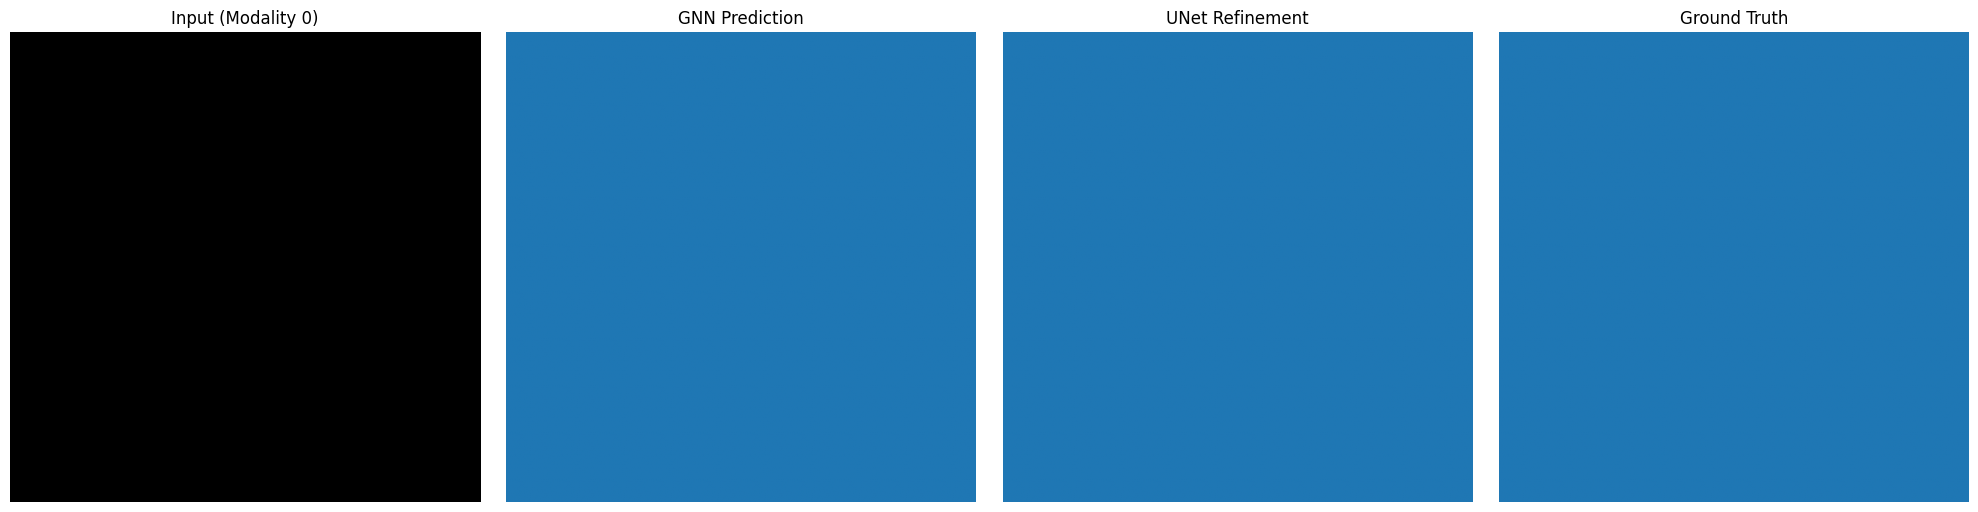


 Processing Slice 2/930


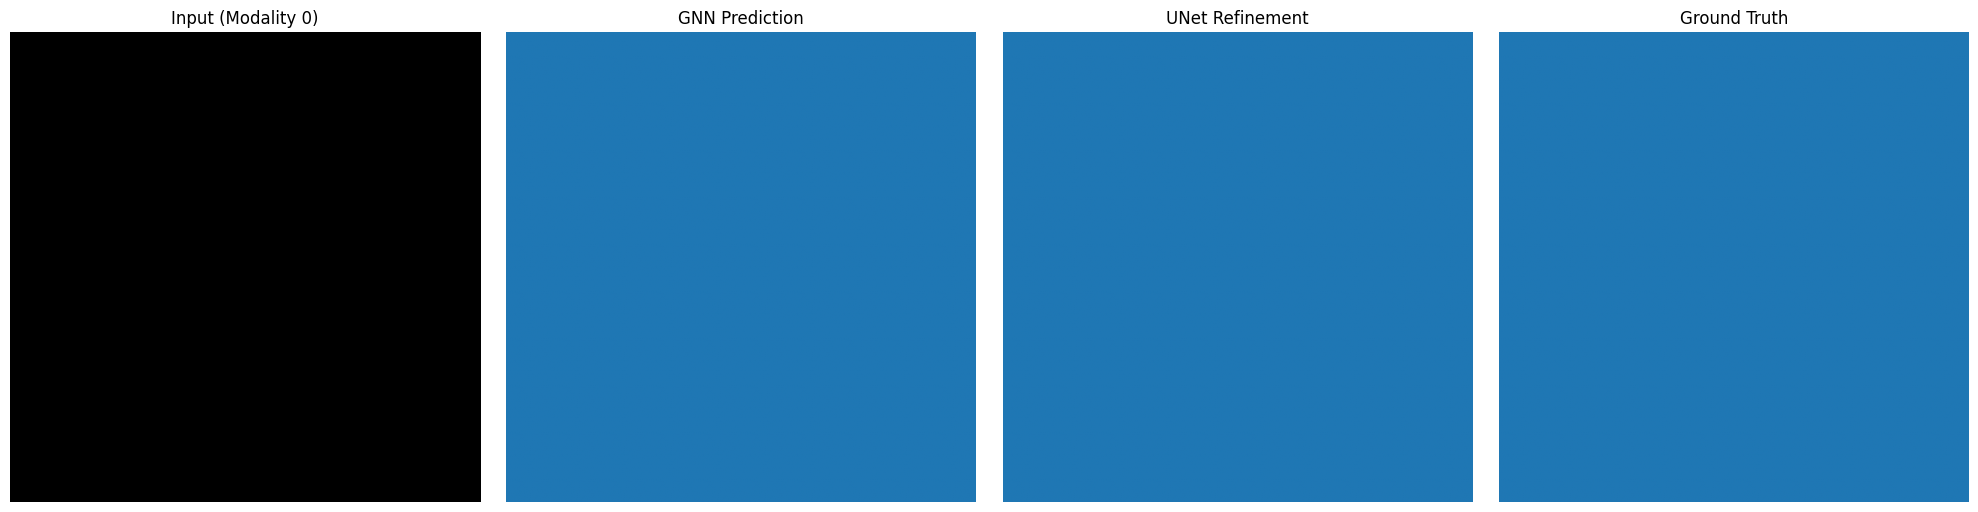


 Processing Slice 3/930


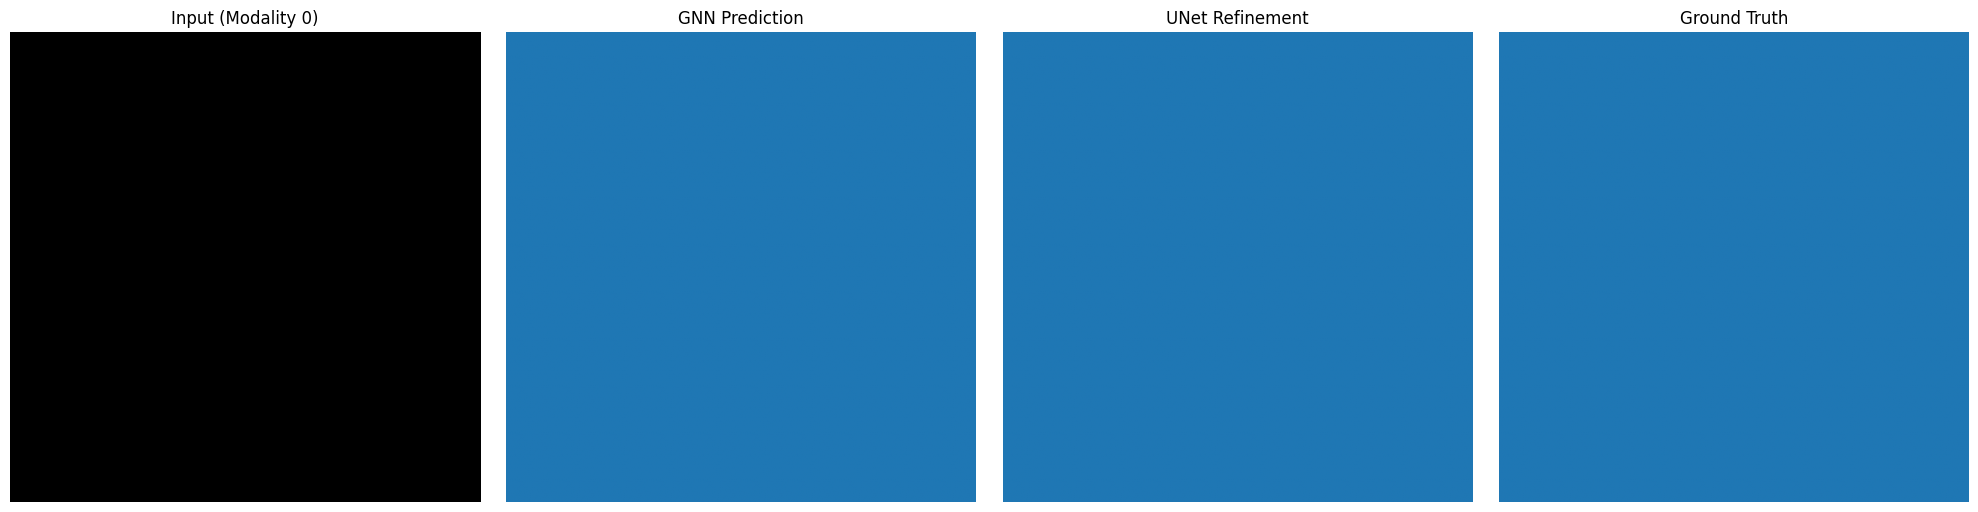


 Processing Slice 4/930


KeyboardInterrupt: 

In [38]:
for i in range(len(test_dataset)):
    print(f"\n Processing Slice {i+1}/{len(test_dataset)}")
    
    sample_image, sample_gt = test_dataset[i]  # [4, H, W], [H, W]
    
    try:
        mask_gnn, mask_unet = visualize_full_pipeline(
            image_slice=sample_image.numpy(),  # input to GNN
            gt_mask=sample_gt.numpy(),         # ground truth
            gnn_model=gnn_model,
            unet_model=unet,
            device=device,
            show=True  # If you want matplotlib plots directly inside this loop
        )
    except Exception as e:
        print(f" Failed on slice {i}: {e}")


# Train/Val

In [42]:
num_epochs = 10
best_dice_mean = -1.0
best_model_state = None
best_epoch = -1


for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    train_loss, _, _ = train_one_epoch(gnn_model, pyg_train_loader, optimizer, loss_fn, device)
    val_loss, val_dice = evaluate_gnn(gnn_model, pyg_val_loader, loss_fn, device)  # val_dice: list or tensor of dice scores
    
    dice_mean = float(torch.tensor(val_dice).mean())  # Convert to mean

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Mean Dice: {dice_mean:.4f} | Per-Class Dice: {[f'{d:.4f}' for d in val_dice]}")

    if dice_mean > best_dice_mean:
        best_dice_mean = dice_mean
        best_model_state = gnn_model.state_dict()
        best_epoch = epoch + 1

# Load best model by mean Dice
gnn_model.load_state_dict(best_model_state)
print(f"\nRestored best model from epoch {best_epoch} with Mean Dice: {best_dice_mean:.4f}")



Epoch 1/10


KeyboardInterrupt: 

# Others

In [24]:
def pyg_from_networkx(G):
    # Localize attributes to reduce dict lookups
    nodes_iter = G.nodes(data=True)
    features = [ndata['features'] for _, ndata in nodes_iter]
    x = torch.as_tensor(features, dtype=torch.float32)

    # Optional labels
    has_label = all('label' in ndata for _, ndata in G.nodes(data=True))
    if has_label:
        labels = [ndata['label'] for _, ndata in G.nodes(data=True)]
        y = torch.as_tensor(labels, dtype=torch.long)
    else:
        y = None

    # Edges
    edge_list = list(G.edges)
    if not edge_list:
        n = G.number_of_nodes()
        edge_index = torch.arange(n, dtype=torch.long).repeat(2, 1)
    else:
        edge_index = torch.as_tensor(edge_list, dtype=torch.long).t().contiguous()
        if not G.is_directed():
            edge_index = torch.cat([edge_index, edge_index[[1, 0]]], dim=1)

    data = Data(x=x, edge_index=edge_index)
    if y is not None:
        data.y = y
    return data

In [29]:


# Convert into graph images
all_graphs = []
for batch_images, batch_labels in tqdm(train_loader, desc="Converting to Graphs (train set)", leave=True):
    graphs = batch_graph_conversion(
        batch_images,
        batch_labels,
        target_segments=700,
        slic_compactness=0.3,
        neighbors=11
    )
    all_graphs.extend(graphs)


val_graphs = []
for batch_images, batch_labels in tqdm(val_loader, desc="Converting to Graphs (val set)", leave=True):
    graphs = batch_graph_conversion(batch_images, batch_labels,
                                     target_segments=700,
                                     slic_compactness=0.3,
                                     neighbors=11)
    val_graphs.extend(graphs)




Converting to Graphs (train set):   0%|          | 0/157 [00:02<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# all_graphs = [(G_nx, sv_map, gt_seg), ...] for 30 slices
pyg_train_dataset = []
graph_train_tuples = []

for G_nx, sv_map, raw_mri, gt_voxel in all_graphs:
    pyg_train_dataset.append(pyg_from_networkx(G_nx))
    graph_train_tuples.append((G_nx, sv_map, raw_mri, gt_voxel))

# Confirm it's 30 graphs
print(f"Converted to PyG dataset: {len(pyg_train_dataset)} graphs")

print(pyg_train_dataset[0])
# ➜ Data(x=[num_nodes, in_feats], edge_index=[2, num_edges], y=[num_nodes])


In [ ]:
from torch_geometric.loader import DataLoader as PyGDataLoader

pyg_train_loader = PyGDataLoader(pyg_train_dataset, batch_size=4, shuffle=True)

for batch in pyg_train_loader:
    print(batch)
    print("x:", batch.x.shape)           # e.g., [total_nodes_in_batch, 20]
    print("y:", batch.y.shape)           # e.g., [total_nodes_in_batch]
    print("edge_index:", batch.edge_index.shape)  # e.g., [2, total_edges]
    print("batch (graph_id):", batch.batch.shape)  # e.g., [total_nodes_in_batch]
    break

pyg_val_dataset = []
graph_val_tuples = []

for G_nx, sv_map, raw_mri, gt_voxel in val_graphs:
    pyg_val_dataset.append(pyg_from_networkx(G_nx))
    graph_val_tuples.append((G_nx, sv_map, raw_mri, gt_voxel))

pyg_val_loader = PyGDataLoader(pyg_val_dataset, batch_size=4, shuffle=False)